# Ingredient Detection - YOLOv5 with 2-Phase Training

End-to-end training notebook for the 207-class ingredients dataset.
Implements the 2-phase freeze/unfreeze strategy:

1. **Offline pre-augmentation**: expands the training set on disk before any
   training begins, using a rich Albumentations pipeline. Rare classes get
   extra copies automatically.
2. **Online YOLO augmentation**: applied in **both** phases.
3. **Phase 1 (50 epochs)**: freeze first 10 backbone layers — only the
   detection head trains. Preserves pretrained features on our small dataset.
4. **Phase 2 (100 epochs)**: load Phase 1 `best.pt`, unfreeze all layers,
   fine-tune end-to-end at ***10 times lower LR*** to avoid catastrophic forgetting.

Run cells top-to-bottom. Each section is self-contained and clearly labelled.

## 1. Install dependencies

In [1]:
!pip install --upgrade pip -q
!pip install ultralytics albumentations tqdm --upgrade -q
!pip install torch --index-url https://download.pytorch.org/whl/cu130 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


## 2. Imports & environment check

In [2]:
import os, shutil, random, math
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm
import yaml
import torch
from ultralytics import YOLO

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'albumentations: {A.__version__}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.9.0+cu126
CUDA: True
GPU: Tesla T4
albumentations: 2.0.8


## 3. Paths & global config

In [3]:
# Source dataset (read-only on Kaggle)
DATASET_PATH = Path('/kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset')
OG_YAML = DATASET_PATH / 'data.yaml'

# Working directories (writable)
WORK_DIR = Path('/kaggle/working')
AUG_DATASET = WORK_DIR / 'aug_dataset'
WEIGHTS_DIR = WORK_DIR / 'weights'
DATA_YAML = WORK_DIR / 'data_aug.yaml'

AUG_DATASET.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# Augmentation hyper-parameters
AUG_CFG = dict(
    copies_per_image  = 2,
    rare_class_thresh = 10,
    rare_class_copies = 4,
    seed = 42,
)

# Phase 1: freeze backbone, train detection head only
# Freeze first 10 backbone layers; only neck + head receive gradients.
# Preserves pretrained ImageNet features on our small ~19 img/class dataset.
PHASE1_CFG = dict(
    model = 'yolov5su.pt',
    epochs = 50,
    imgsz = 640,
    batch = 16,
    device = 0 if torch.cuda.is_available() else 'cpu',
    workers = 8,
    patience = 30,
    save = True,
    save_period = 10,
    cache = False,
    optimizer = 'AdamW',
    lr0 = 0.001,
    lrf = 0.1,
    momentum = 0.937,
    weight_decay = 0.0005,
    warmup_epochs = 3.0,
    warmup_momentum = 0.8,
    warmup_bias_lr = 0.1,
    box = 7.5,
    cls = 0.5,
    freeze = 10,
    name = 'phase1_head',
    # online augmentation
    hsv_h = 0.02,
    hsv_s = 0.75,
    hsv_v = 0.45,
    degrees = 10.0,
    translate = 0.1,
    scale = 0.5,
    shear = 2.0,
    perspective = 0.001,
    flipud = 0.1,
    fliplr = 0.5,
    mosaic = 1.0,
    mixup = 0.1,
)

# Phase 2: full fine-tune starting from Phase 1 best weights
# Unfreeze all layers; fine-tune end-to-end at 10x lower LR.
PHASE2_CFG = dict(
    # model path set at runtime from PHASE1_BEST
    epochs = 100,
    imgsz = 640,
    batch = 16,
    device = 0 if torch.cuda.is_available() else 'cpu',
    workers = 8,
    patience = 50,
    save = True,
    save_period = 10,
    cache = False,
    optimizer = 'AdamW',
    lr0 = 0.0001,
    lrf = 0.1,
    momentum = 0.937,
    weight_decay = 0.0005,
    warmup_epochs = 2.0,
    warmup_momentum = 0.8,
    warmup_bias_lr = 0.01,
    box = 7.5,
    cls = 0.5,
    freeze = 0,
    name = 'phase2_full',
    # online augmentation (identical to Phase 1)
    hsv_h = 0.02,
    hsv_s = 0.75,
    hsv_v = 0.45,
    degrees = 10.0,
    translate  = 0.1,
    scale = 0.5,
    shear = 2.0,
    perspective = 0.001,
    flipud = 0.1,
    fliplr = 0.5,
    mosaic = 1.0,
    mixup = 0.1,
)

random.seed(AUG_CFG['seed'])
np.random.seed(AUG_CFG['seed'])
print('Config ready — 2-phase training enabled.')
print(f'Phase 1: {PHASE1_CFG["epochs"]} epochs, freeze={PHASE1_CFG["freeze"]}, lr0={PHASE1_CFG["lr0"]}')
print(f'Phase 2: {PHASE2_CFG["epochs"]} epochs, freeze={PHASE2_CFG["freeze"]}, lr0={PHASE2_CFG["lr0"]}')


Config ready — 2-phase training enabled.
Phase 1: 50 epochs, freeze=10, lr0=0.001
Phase 2: 100 epochs, freeze=0, lr0=0.0001


## **4. Load dataset YAML**

In [4]:
with open(OG_YAML, 'r') as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg['names'] # list of 207 class names
NC = data_cfg['nc'] # 207

print(f'Classes: {NC}')
print(f'First 5: {CLASS_NAMES[:5]}')
print(f'Last 5: {CLASS_NAMES[-5:]}')


Classes: 207
First 5: ['agar agar powder', 'alsa powder', 'annatto oil', 'bamboo shoot', 'banana']
Last 5: ['wine', 'winter melon', 'wonton', 'wood ear mushroom', 'yeast']


## **5. Albumentations augmentation pipeline**

In [5]:
def build_pipeline(p: float = 0.6) -> A.Compose:
    """
    Bbox-safe augmentation pipeline in YOLO format.

    Designed for food / ingredient photography:
    - Colour transforms simulate different lighting environments
      (market stalls, restaurant kitchens, home counters).
    - Noise / blur mimic phone-camera conditions.
    - Shadow / fog simulate outdoor wet-market scenes.
    - Geometry ops are kept mild to avoid destroying small objects.
    """
    return A.Compose(
        [
            # Colour / lighting
            A.ColorJitter(
                brightness=0.3, contrast=0.3,
                saturation=0.3, hue=0.05, p=p
            ),
            A.HueSaturationValue(
                hue_shift_limit=15, sat_shift_limit=30,
                val_shift_limit=20, p=p
            ),
            A.RandomBrightnessContrast(
                brightness_limit=0.25, contrast_limit=0.25, p=p
            ),
            A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=p * 0.5),
            A.RandomShadow(p=p * 0.3),
            A.RandomFog(fog_coef_range=(0.05, 0.2), p=p * 0.2),

            # Noise / blur
            A.GaussNoise(std_range=(0.012, 0.028), p=p * 0.4),
            A.ISONoise(
                color_shift=(0.01, 0.05),
                intensity=(0.1, 0.5), p=p * 0.3
            ),
            A.OneOf([
                A.MotionBlur(blur_limit=5),
                A.MedianBlur(blur_limit=5),
                A.Blur(blur_limit=5),
            ], p=p * 0.3),

            # Resolution
            A.Downscale(scale_range=(0.5, 0.9), p=p * 0.2),

            # Geometry (bbox-safe)
            A.Affine(
                translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
                scale=(0.9, 1.1), # 1 ± scale_limit
                rotate=(-10, 10),
                border_mode=cv2.BORDER_REFLECT_101,
                p=p
            ),
            A.Perspective(scale=(0.02, 0.05), p=p * 0.3),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.1),
        ],
        bbox_params=A.BboxParams(
            format='yolo',
            label_fields=['class_labels'],
            min_visibility=0.3, # drop boxes that become <30% visible
        )
    )


PIPELINE = build_pipeline(p=0.65)
print('Pipeline built.')


Pipeline built.


## **6. Label I/O helpers**

In [6]:
def read_label(label_path: Path):
    """Return (class_ids: list[int], boxes: list[[cx,cy,w,h]])."""
    class_ids, boxes = [], []
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) == 5:
                class_ids.append(int(parts[0]))
                boxes.append([float(x) for x in parts[1:]])
    return class_ids, boxes


def write_label(label_path: Path, class_ids, boxes):
    """Write YOLO label file from class_ids and boxes."""
    lines = [
        f'{int(cls_id)} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}'
        for cls_id, (cx, cy, bw, bh) in zip(class_ids, boxes)
    ]
    label_path.write_text('\n'.join(lines))


def _sanitise_yolo_boxes(boxes):
    """
    Clamp YOLO (cx, cy, w, h) boxes so that their pascal_voc conversion
    stays strictly within [0, 1]. Albumentations validates bboxes when it
    converts internally, so a source coordinate like cy=0.49996, h=0.99993
    produces y_min = -5e-7 and raises before any transform even runs.
    """
    clean = []
    for box in boxes:
        cx, cy, bw, bh = box
        # Clamp w/h to (0, 1]
        bw = float(np.clip(bw, 1e-6, 1.0))
        bh = float(np.clip(bh, 1e-6, 1.0))
        # Clamp cx/cy so that x_min/y_min >= 0 and x_max/y_max <= 1
        cx = float(np.clip(cx, bw / 2.0, 1.0 - bw / 2.0))
        cy = float(np.clip(cy, bh / 2.0, 1.0 - bh / 2.0))
        clean.append((cx, cy, bw, bh))
    return clean


def augment_sample(img_bgr, class_ids, boxes, pipeline):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # Sanitise INPUT boxes before Albumentations converts to pascal_voc internally.
    # Epsilon drift (e.g. -5e-7) in source labels causes validation errors inside
    # the pipeline, before any transform runs.
    safe_boxes = _sanitise_yolo_boxes(boxes)
    out = pipeline(
        image=img_rgb,
        bboxes=safe_boxes,
        class_labels=class_ids,
    )
    # Clamp OUTPUT boxes too — transforms can reintroduce epsilon drift.
    clean_boxes = [
        tuple(min(1.0, max(0.0, v)) for v in box)
        for box in out['bboxes']
    ]
    return out['image'], list(out['class_labels']), clean_boxes


print('Label helpers ready.')


Label helpers ready.


In [7]:
src_img_dir = DATASET_PATH / data_cfg['train']
src_lbl_dir = src_img_dir.parent / 'labels'

# Count instances per class across the entire training set
class_instance_count: Counter = Counter()
img_to_classes: dict = {}   # img_stem → set of class ids present

all_train_imgs = sorted(src_img_dir.glob('*.*'))
for img_path in tqdm(all_train_imgs, desc='Scanning labels'):
    lbl_path = src_lbl_dir / (img_path.stem + '.txt')
    class_ids, _ = read_label(lbl_path)
    for cid in class_ids:
        class_instance_count[cid] += 1
    img_to_classes[img_path.stem] = set(class_ids)

# Which classes are rare?
THRESH = AUG_CFG['rare_class_thresh']
rare_classes = {cid for cid, cnt in class_instance_count.items() if cnt < THRESH}
print(f'Total training images : {len(all_train_imgs)}')
print(f'Rare classes (<{THRESH} instances): {len(rare_classes)}')
if rare_classes:
    print('  ' + ', '.join(CLASS_NAMES[c] for c in sorted(rare_classes)))


Scanning labels:   0%|          | 0/3838 [00:00<?, ?it/s]

Total training images : 3838
Rare classes (<10 instances): 3
  beef stock, egg white, rice flour


## **7. Count class frequencies for rare-class oversampling**

## **8. Offline augmentation - build augmented training split**

In [8]:
# Output dirs
aug_img_dir = AUG_DATASET / 'train' / 'images'
aug_lbl_dir = AUG_DATASET / 'train' / 'labels'
aug_img_dir.mkdir(parents=True, exist_ok=True)
aug_lbl_dir.mkdir(parents=True, exist_ok=True)

COPIES = AUG_CFG['copies_per_image']
RARE_COPIES = AUG_CFG['rare_class_copies']
errors = []

for img_path in tqdm(all_train_imgs, desc='Augmenting train'):
    stem = img_path.stem
    lbl_path = src_lbl_dir / (stem + '.txt')
    class_ids, boxes = read_label(lbl_path)

    # Decide how many augmented copies to make
    is_rare = bool(img_to_classes.get(stem, set()) & rare_classes)
    n_copies = RARE_COPIES if is_rare else COPIES

    try:
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            raise ValueError('Could not read image')

        # 1. Always copy the original (unchanged)
        dst_img = aug_img_dir / img_path.name
        dst_lbl = aug_lbl_dir / (stem + '.txt')
        shutil.copy2(img_path, dst_img)
        
        # if class_ids:
        #     write_label(dst_lbl, class_ids, boxes)
        
        write_label(dst_lbl, class_ids, boxes)

        # 2. Generate augmented copies
        for k in range(n_copies):
            aug_img, aug_cls, aug_boxes = augment_sample(
                img_bgr, class_ids, boxes, PIPELINE
            )
            ext = img_path.suffix
            out_stem = f'{stem}_aug{k}'
            out_img = aug_img_dir / f'{out_stem}{ext}'
            out_lbl = aug_lbl_dir / f'{out_stem}.txt'

            cv2.imwrite(
                str(out_img),
                cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)
            )
            if aug_cls:
                write_label(out_lbl, aug_cls, aug_boxes)

    except Exception as e:
        errors.append((img_path.name, str(e)))

total_aug = len(list(aug_img_dir.glob('*.*')))
print(f'\nOriginal images: {len(all_train_imgs)}')
print(f'Augmented total: {total_aug}')
print(f'Expansion factor: {total_aug / max(len(all_train_imgs),1):.1f}x')
if errors:
    print(f'Errors ({len(errors)}):', errors[:5])


Augmenting train:   0%|          | 0/3838 [00:00<?, ?it/s]

libpng warning: eXIf: duplicate
libpng warning: iCCP: profile 'icc': 0h: PCS illuminant is not D50
libpng warning: iCCP: extra compressed data



Original images: 3838
Augmented total: 11528
Expansion factor: 3.0x
Errors (15): [('coconut water_image_2.jfif', "OpenCV(4.12.0) /io/opencv/modules/imgcodecs/src/loadsave.cpp:1051: error: (-2:Unspecified error) could not find a writer for the specified extension in function 'imwrite_'\n"), ('corn starch_image_3.jfif', "OpenCV(4.12.0) /io/opencv/modules/imgcodecs/src/loadsave.cpp:1051: error: (-2:Unspecified error) could not find a writer for the specified extension in function 'imwrite_'\n"), ('egg roll wrapper_image_10.jfif', "OpenCV(4.12.0) /io/opencv/modules/imgcodecs/src/loadsave.cpp:1051: error: (-2:Unspecified error) could not find a writer for the specified extension in function 'imwrite_'\n"), ('egg roll wrapper_image_6.jfif', "OpenCV(4.12.0) /io/opencv/modules/imgcodecs/src/loadsave.cpp:1051: error: (-2:Unspecified error) could not find a writer for the specified extension in function 'imwrite_'\n"), ('egg roll wrapper_image_7.jfif', "OpenCV(4.12.0) /io/opencv/modules/imgcode

## **9. Wire up val/test splits & write data YAML**

In [9]:
# Val and test remain the original (no augmentation on eval splits)
for split in ('val', 'test'):
    for kind in ('images', 'labels'):
        src = DATASET_PATH / split / kind
        dst = AUG_DATASET / split / kind
        if dst.exists() or dst.is_symlink():
            pass  # already there
        else:
            dst.parent.mkdir(parents=True, exist_ok=True)
            os.symlink(src.resolve(), dst)

# Write a new data.yaml that points at our augmented dataset
new_yaml = {
    'path': str(AUG_DATASET),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': NC,
    'names': CLASS_NAMES,
}
with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(new_yaml, f, sort_keys=False, allow_unicode=True)

print(f'data YAML written → {DATA_YAML}')

# Quick sanity-check
with open(DATA_YAML) as f:
    check = yaml.safe_load(f)
print(f'train images: {aug_img_dir}')
print(f'val images: {AUG_DATASET / "val" / "images"}')
print(f'nc: {check["nc"]}')

data YAML written → /kaggle/working/data_aug.yaml
train images: /kaggle/working/aug_dataset/train/images
val images: /kaggle/working/aug_dataset/val/images
nc: 207


## 10. Visualise a few augmented samples

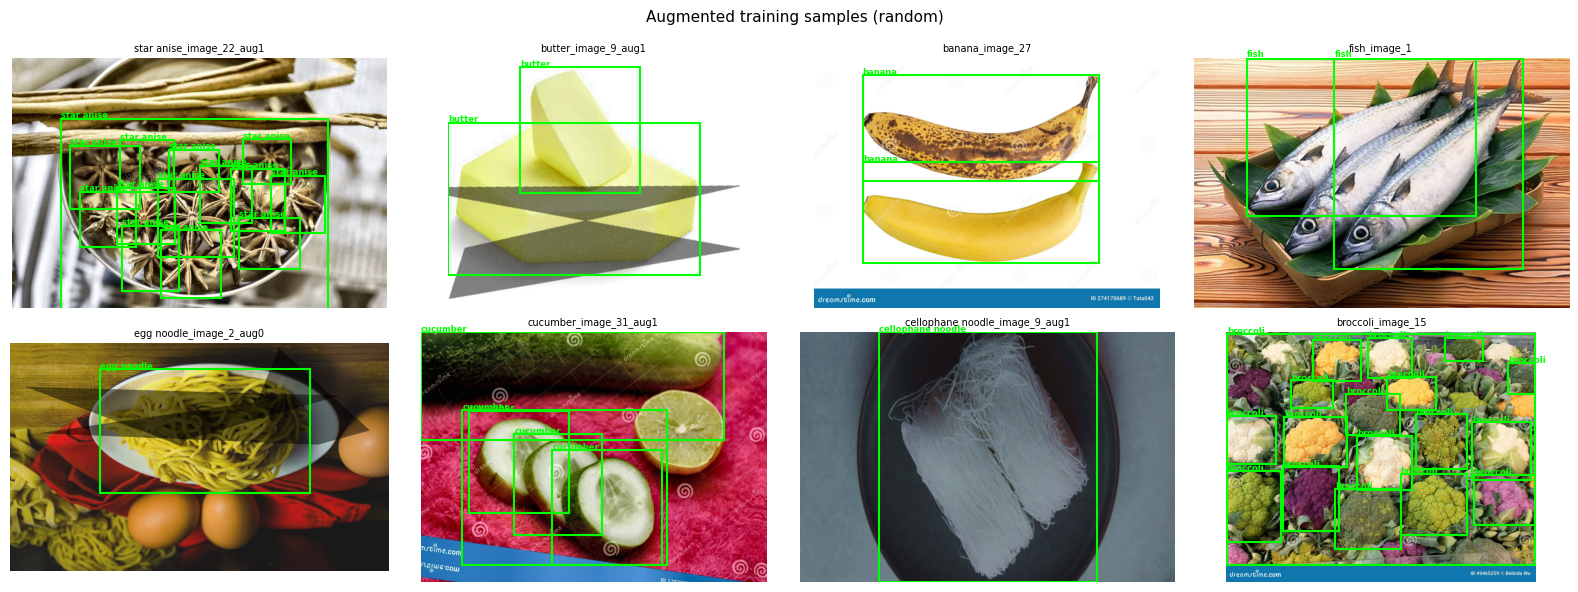

In [10]:
def yolo_to_xyxy(box, w, h):
    cx, cy, bw, bh = box
    return (cx - bw/2)*w, (cy - bh/2)*h, (cx + bw/2)*w, (cy + bh/2)*h

def show_sample_grid(img_dir: Path, lbl_dir: Path, n: int = 8, title=''):
    imgs = sorted(img_dir.glob('*.*'))
    sample = random.sample(imgs, min(n, len(imgs)))
    cols = 4
    rows = math.ceil(len(sample) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = np.array(axes).flatten()
    for ax, img_path in zip(axes, sample):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        lbl = lbl_dir / (img_path.stem + '.txt')
        class_ids, boxes = read_label(lbl)
        ax.imshow(img)
        h, w = img.shape[:2]
        for cls_id, box in zip(class_ids, boxes):
            x1, y1, x2, y2 = yolo_to_xyxy(box, w, h)
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=1.5, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1-4, CLASS_NAMES[cls_id],
                    color='lime', fontsize=6, fontweight='bold')
        ax.set_title(img_path.stem[:30], fontsize=7)
        ax.axis('off')
    for ax in axes[len(sample):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


# Show 8 random augmented training images
show_sample_grid(
    aug_img_dir, aug_lbl_dir,
    n=8, title='Augmented training samples (random)'
)


## 11. Post-augmentation class distribution

Counting aug labels: 0it [00:00, ?it/s]

Class                            Before    After      Δ
--------------------------------------------------------
beef stock                            8       40    +32
egg white                             6       30    +24
rice flour                            9       45    +36


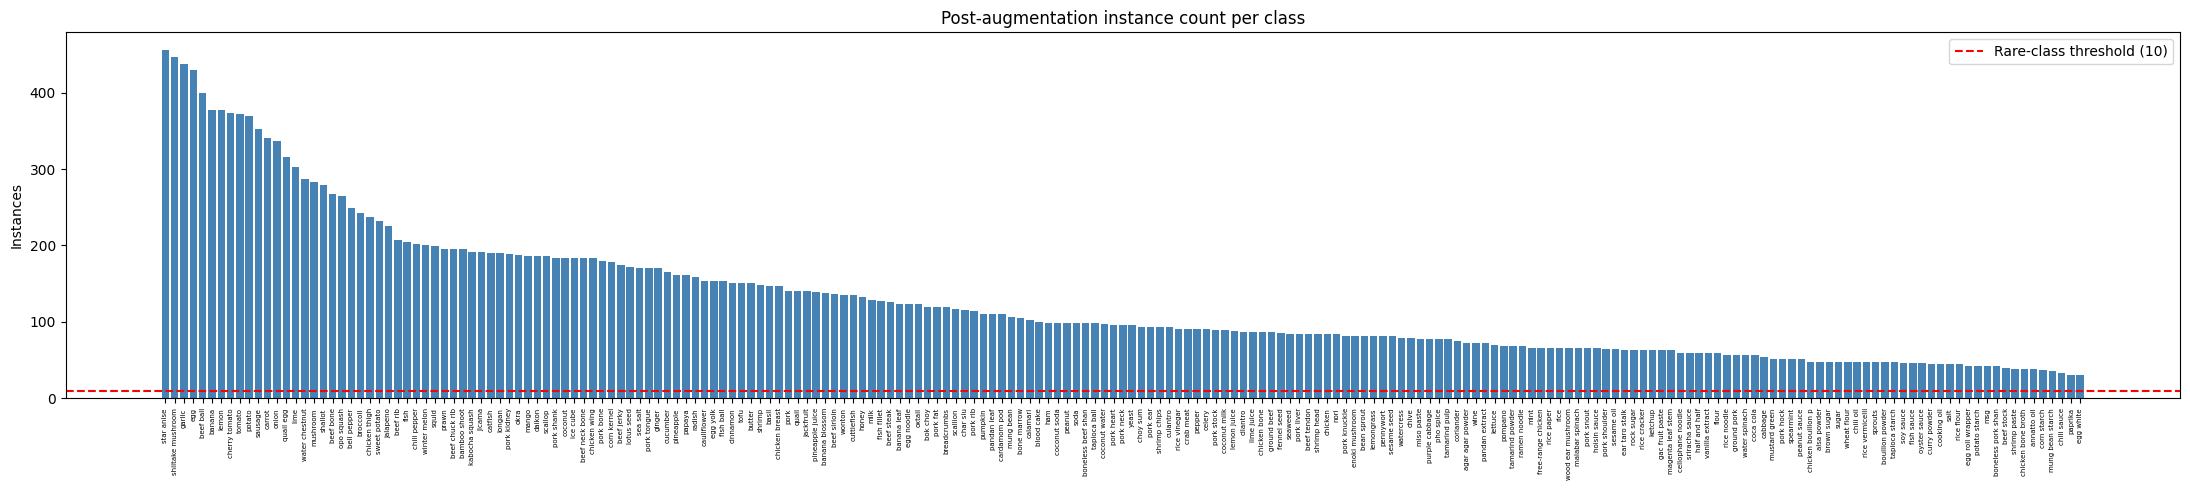

In [11]:
aug_counts: Counter = Counter()
for lbl_file in tqdm(aug_lbl_dir.glob('*.txt'), desc='Counting aug labels'):
    class_ids, _ = read_label(lbl_file)
    for cid in class_ids:
        aug_counts[cid] += 1

orig_counts = class_instance_count   # counted in Cell 7

# Compare rare-class counts before vs after
print(f'{'Class':<30} {'Before':>8} {'After':>8} {'Δ':>6}')
print('-' * 56)
for cid in sorted(rare_classes):
    before = orig_counts.get(cid, 0)
    after = aug_counts.get(cid, 0)
    name = CLASS_NAMES[cid]
    print(f'{name:<30} {before:>8} {after:>8} {after-before:>+6}')

# Bar chart — full distribution
sorted_ids = sorted(aug_counts, key=aug_counts.get, reverse=True)
names_s = [CLASS_NAMES[i][:18] for i in sorted_ids]
vals_s = [aug_counts[i] for i in sorted_ids]

fig, ax = plt.subplots(figsize=(22, 5))
ax.bar(range(len(vals_s)), vals_s, color='steelblue', width=0.8)
ax.set_xticks(range(len(names_s)))
ax.set_xticklabels(names_s, rotation=90, fontsize=5)
ax.axhline(AUG_CFG['rare_class_thresh'], color='red', linestyle='--',
           label=f'Rare-class threshold ({AUG_CFG["rare_class_thresh"]})')
ax.set_title('Post-augmentation instance count per class')
ax.set_ylabel('Instances')
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
# DATASET HEALTH CHECK — run before training

import random

def check_dataset_health(img_dir: Path, lbl_dir: Path, split: str, sample_n: int = 5):
    imgs = sorted(img_dir.glob('*.*'))
    lbls = sorted(lbl_dir.glob('*.txt'))

    img_stems = {p.stem for p in imgs}
    lbl_stems = {p.stem for p in lbls}

    imgs_no_label = img_stems - lbl_stems   # images with no label file
    labels_no_img = lbl_stems - img_stems   # orphaned label files

    # Count total instances across all labels
    total_instances = 0
    empty_labels = 0
    corrupt_labels = 0
    for lbl in lbls:
        try:
            ids, boxes = read_label(lbl)
            if not ids:
                empty_labels += 1
            total_instances += len(ids)
        except Exception:
            corrupt_labels += 1

    print(f'\n{"="*55}')
    print(f'Split: {split}')
    print(f'{"="*55}')
    print(f'Images: {len(imgs)}')
    print(f'Label files: {len(lbls)}')
    print(f'Total instances: {total_instances}')
    print(f'Avg inst/image: {total_instances / max(len(imgs), 1):.2f}')
    print(f'Empty labels: {empty_labels}')
    print(f'Corrupt labels: {corrupt_labels}')
    print(f'Images w/o lbl: {len(imgs_no_label)}  {"⚠️  BAD" if imgs_no_label else "✅"}')
    print(f'Orphan labels: {len(labels_no_img)}  {"⚠️  BAD" if labels_no_img else "✅"}')

    # Spot-check a few random label files
    print(f'\n  --- {sample_n} random label samples ---')
    for lbl in random.sample(lbls, min(sample_n, len(lbls))):
        ids, boxes = read_label(lbl)
        print(f'  {lbl.name:<45} {len(ids)} instances  classes={ids[:3]}{"..." if len(ids)>3 else ""}')

    # Overall verdict
    healthy = (
        len(imgs) > 0 and
        total_instances > 0 and
        len(imgs_no_label) / max(len(imgs), 1) < 0.05  # allow <5% background
    )
    print(f'\n  Verdict: {"HEALTHY - safe to train" if healthy else "UNHEALTHY — fix before training"}')
    return healthy


# ── Check all three splits ────────────────────────────────────────────────────
train_healthy = check_dataset_health(
    aug_img_dir,
    aug_lbl_dir,
    split='train (augmented)'
)

val_healthy = check_dataset_health(
    AUG_DATASET / 'val'  / 'images',
    AUG_DATASET / 'val'  / 'labels',
    split='val'
)

test_healthy = check_dataset_health(
    AUG_DATASET / 'test' / 'images',
    AUG_DATASET / 'test' / 'labels',
    split='test'
)

# ── Final gate ────────────────────────────────────────────────────────────────
print('\n' + '='*55)
if all([train_healthy, val_healthy, test_healthy]):
    print('ALL SPLITS HEALTHY — proceed to training')
else:
    print('ONE OR MORE SPLITS FAILED — do NOT train yet')
    print('Re-run Section 8 (aug loop) and check paths in Section 9.')
print('='*55)


Split: train (augmented)
Images: 11528
Label files: 11516
Total instances: 26684
Avg inst/image: 2.31
Empty labels: 0
Corrupt labels: 0
Images w/o lbl: 0  ✅
Orphan labels: 0  ✅

  --- 5 random label samples ---
  water chestnut_image_39_aug1.txt              5 instances  classes=[198, 198, 198]...
  rice flour_image_10_aug2.txt                  1 instances  classes=[162]
  bok choy_image_8_aug0.txt                     1 instances  classes=[22]
  sesame oil_image_10.txt                       1 instances  classes=[174]
  pandan extract_image_7_aug0.txt               2 instances  classes=[123, 123]

  Verdict: HEALTHY - safe to train

Split: val
Images: 651
Label files: 651
Total instances: 1411
Avg inst/image: 2.17
Empty labels: 0
Corrupt labels: 0
Images w/o lbl: 0  ✅
Orphan labels: 0  ✅

  --- 5 random label samples ---
  bean sprout_image_9.txt                       1 instances  classes=[8]
  bean sprout_image_19.txt                      1 instances  classes=[8]
  broccoli_image_18.t

## 12. Phase 1 — Train detection head (backbone frozen)

In [13]:
# ── Phase 1: freeze first 10 backbone layers ───────────────────────────────
# Only the detection head + neck weights receive gradient updates.
# This lets the head learn class semantics without disturbing pretrained
# backbone features on our small ~19 img/class dataset.

print('=' * 80)
print('PHASE 1 — Detection head training (backbone frozen)')
print(f'  Epochs : {PHASE1_CFG["epochs"]}')
print(f'  Freeze : first {PHASE1_CFG["freeze"]} backbone layers')
print(f'  LR     : {PHASE1_CFG["lr0"]}')
print('=' * 80)

model_p1 = YOLO(PHASE1_CFG['model'])

results_p1 = model_p1.train(
    data = str(DATA_YAML),
    epochs = PHASE1_CFG['epochs'],
    imgsz = PHASE1_CFG['imgsz'],
    batch = PHASE1_CFG['batch'],
    device = PHASE1_CFG['device'],
    workers = PHASE1_CFG['workers'],
    patience = PHASE1_CFG['patience'],
    save = PHASE1_CFG['save'],
    save_period = PHASE1_CFG['save_period'],
    cache = PHASE1_CFG['cache'],
    optimizer = PHASE1_CFG['optimizer'],
    lr0 = PHASE1_CFG['lr0'],
    lrf = PHASE1_CFG['lrf'],
    momentum = PHASE1_CFG['momentum'],
    weight_decay = PHASE1_CFG['weight_decay'],
    warmup_epochs = PHASE1_CFG['warmup_epochs'],
    warmup_momentum = PHASE1_CFG['warmup_momentum'],
    warmup_bias_lr = PHASE1_CFG['warmup_bias_lr'],
    box = PHASE1_CFG['box'],
    cls = PHASE1_CFG['cls'],
    freeze = PHASE1_CFG['freeze'],
    # online augmentation
    hsv_h = PHASE1_CFG['hsv_h'],
    hsv_s = PHASE1_CFG['hsv_s'],
    hsv_v = PHASE1_CFG['hsv_v'],
    degrees = PHASE1_CFG['degrees'],
    translate = PHASE1_CFG['translate'],
    scale = PHASE1_CFG['scale'],
    shear = PHASE1_CFG['shear'],
    perspective = PHASE1_CFG['perspective'],
    flipud = PHASE1_CFG['flipud'],
    fliplr = PHASE1_CFG['fliplr'],
    mosaic = PHASE1_CFG['mosaic'],
    mixup = PHASE1_CFG['mixup'],
    project = str(WEIGHTS_DIR),
    name = PHASE1_CFG['name'],
    exist_ok = True,
    pretrained = True,
    verbose = True,
)

# Locate the best checkpoint from Phase 1
PHASE1_BEST = WEIGHTS_DIR / PHASE1_CFG['name'] / 'weights' / 'best.pt'
assert PHASE1_BEST.exists(), f'Phase 1 best.pt not found at {PHASE1_BEST}'

print('\n' + '=' * 80)
print(f'Phase 1 complete!  Best weights → {PHASE1_BEST}')
p1_map = results_p1.results_dict.get('metrics/mAP50(B)', 'n/a')
print(f'Phase 1 best mAP50: {p1_map}')
print('=' * 80)


PHASE 1 — Detection head training (backbone frozen)
  Epochs : 50
  Freeze : first 10 backbone layers
  LR     : 0.001
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_aug.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.02, hsv_s=0.75, hsv_v=0.45, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov5su.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name

libpng warning: iCCP: extra compressed data


val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 23.0±21.2 MB/s, size: 164.1 KB)
val: Scanning /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/labels... 650 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 651/651 294.3it/s 2.2s
val: /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/images/tomato_image_16.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/images/tomato_image_16.jpg'
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val is not writable, cache not saved.
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 69 weight(decay=0.0), 76 weight(decay=0.0005), 75 bias(decay=0.0)
Plotting labels to /kaggle/working/weights/phase1_head/labels.jpg... 
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /kaggle/working/weights/phase1_he

libpng warning: iCCP: profile 'icc': 0h: PCS illuminant is not D50


       1/50      2.54G       1.34       4.24      1.733         97        640: 98% ━━━━━━━━━━━╸ 703/720 4.3it/s 3:04<3.9s

...

      50/50      6.81G     0.8943      1.003      1.407         30        640: 88% ━━━━━━━━━━╸─ 631/720 4.2it/s 2:25<21.3s

libpng warning: eXIf: duplicate


      50/50      6.81G     0.8938      1.005      1.406         35        640: 97% ━━━━━━━━━━━╸ 698/720 4.1it/s 2:41<5.4s

libpng warning: iCCP: profile 'icc': 0h: PCS illuminant is not D50


      50/50      6.81G     0.8937      1.005      1.407         11        640: 100% ━━━━━━━━━━━━ 720/720 4.4it/s 2:46
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 3.8it/s 5.5s
                   all        650       1409      0.551      0.532       0.59      0.416

50 epochs completed in 2.615 hours.
Optimizer stripped from /kaggle/working/weights/phase1_head/weights/last.pt, 18.7MB
Optimizer stripped from /kaggle/working/weights/phase1_head/weights/best.pt, 18.7MB

Validating /kaggle/working/weights/phase1_head/weights/best.pt...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5s summary (fused): 85 layers, 9,191,645 parameters, 0 gradients, 24.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 3.5it/s 6.0s
                   all        650       1409       0.52      0.569      0.595      0.418
      agar ag

## 13. Phase 2 — Full fine-tune (all layers unfrozen)

In [14]:
# ── Phase 2: unfreeze all layers, fine-tune end-to-end ──────────────────────
# Load Phase 1 best weights and resume with a 10× lower LR so the backbone
# can adapt gently to ingredient textures without overwriting head gains.

print('=' * 80)
print('PHASE 2 — Full fine-tune (all layers unfrozen)')
print(f'Starting from: {PHASE1_BEST}')
print(f'Epochs: {PHASE2_CFG["epochs"]}')
print(f'Freeze: {PHASE2_CFG["freeze"]} (none)')
print(f'LR: {PHASE2_CFG["lr0"]} (10× lower than Phase 1)')
print('=' * 80)

model_p2 = YOLO(str(PHASE1_BEST))  # warm-start from Phase 1 best

results_p2 = model_p2.train(
    data = str(DATA_YAML),
    epochs = PHASE2_CFG['epochs'],
    imgsz = PHASE2_CFG['imgsz'],
    batch = PHASE2_CFG['batch'],
    device = PHASE2_CFG['device'],
    workers = PHASE2_CFG['workers'],
    patience = PHASE2_CFG['patience'],
    save = PHASE2_CFG['save'],
    save_period = PHASE2_CFG['save_period'],
    cache = PHASE2_CFG['cache'],
    optimizer = PHASE2_CFG['optimizer'],
    lr0 = PHASE2_CFG['lr0'],
    lrf = PHASE2_CFG['lrf'],
    momentum = PHASE2_CFG['momentum'],
    weight_decay = PHASE2_CFG['weight_decay'],
    warmup_epochs = PHASE2_CFG['warmup_epochs'],
    warmup_momentum = PHASE2_CFG['warmup_momentum'],
    warmup_bias_lr = PHASE2_CFG['warmup_bias_lr'],
    box = PHASE2_CFG['box'],
    cls = PHASE2_CFG['cls'],
    freeze = PHASE2_CFG['freeze'],
    # online augmentation
    hsv_h = PHASE2_CFG['hsv_h'],
    hsv_s = PHASE2_CFG['hsv_s'],
    hsv_v = PHASE2_CFG['hsv_v'],
    degrees = PHASE2_CFG['degrees'],
    translate = PHASE2_CFG['translate'],
    scale = PHASE2_CFG['scale'],
    shear = PHASE2_CFG['shear'],
    perspective = PHASE2_CFG['perspective'],
    flipud = PHASE2_CFG['flipud'],
    fliplr = PHASE2_CFG['fliplr'],
    mosaic = PHASE2_CFG['mosaic'],
    mixup = PHASE2_CFG['mixup'],
    project = str(WEIGHTS_DIR),
    name = PHASE2_CFG['name'],
    exist_ok = True,
    pretrained = True,
    verbose = True,
)

PHASE2_BEST = WEIGHTS_DIR / PHASE2_CFG['name'] / 'weights' / 'best.pt'

print('\n' + '=' * 80)
print('Phase 2 complete!')
p2_map = results_p2.results_dict.get('metrics/mAP50(B)', 'n/a')
print(f'Phase 1 mAP50: {p1_map}')
print(f'Phase 2 mAP50: {p2_map}')
print(f'Best weights saved to {PHASE2_BEST}')
print('=' * 80)

PHASE 2 — Full fine-tune (all layers unfrozen)
Starting from: /kaggle/working/weights/phase1_head/weights/best.pt
Epochs: 100
Freeze: 0 (none)
LR: 0.0001 (10× lower than Phase 1)
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_aug.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.02, hsv_s=0.75, hsv_v=0.45, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/

libpng warning: iCCP: extra compressed data


val: Scanning /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/labels... 650 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 651/651 546.5it/s 1.2s
val: /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/images/tomato_image_16.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/images/tomato_image_16.jpg'
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val is not writable, cache not saved.
optimizer: AdamW(lr=0.0001, momentum=0.937) with parameter groups 69 weight(decay=0.0), 76 weight(decay=0.0005), 75 bias(decay=0.0)
Plotting labels to /kaggle/working/weights/phase2_full/labels.jpg... 
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /kaggle/working/weights/phase2_full
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_l

libpng warning: iCCP: profile 'icc': 0h: PCS illuminant is not D50


      1/100      4.53G      1.124      2.003      1.496         67        640: 97% ━━━━━━━━━━━╸ 697/720 3.3it/s 3:35<6.9s

...

    100/100      4.38G     0.7093     0.6345      1.241         46        640: 37% ━━━━──────── 263/720 3.4it/s 1:16<2:13

libpng warning: eXIf: duplicate


    100/100      4.38G     0.7081     0.6324      1.239         35        640: 58% ━━━━━━━───── 421/720 3.5it/s 2:01<1:26

libpng warning: iCCP: extra compressed data


    100/100      4.38G     0.7074     0.6326       1.24         23        640: 100% ━━━━━━━━━━━━ 720/720 3.5it/s 3:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 3.9it/s 5.4s
                   all        650       1409      0.599      0.622      0.662      0.531

100 epochs completed in 6.111 hours.
Optimizer stripped from /kaggle/working/weights/phase2_full/weights/last.pt, 18.7MB
Optimizer stripped from /kaggle/working/weights/phase2_full/weights/best.pt, 18.7MB

Validating /kaggle/working/weights/phase2_full/weights/best.pt...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5s summary (fused): 85 layers, 9,191,645 parameters, 0 gradients, 24.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 3.6it/s 5.8s
                   all        650       1409      0.604      0.621      0.663      0.532
      agar a

## 14. Validate

In [15]:
# Validate the Phase 2 model (best full fine-tune weights)
metrics = model_p2.val(
    data=str(DATA_YAML),
    device=PHASE2_CFG['device'],
    imgsz=PHASE2_CFG['imgsz'],
)
# print(metrics)

print(f'\nValidation Results')
print(f'mAP50: {metrics.box.map50:.4f}')
print(f'mAP50-95: {metrics.box.map:.4f}')
print(f'Precision: {metrics.box.mp:.4f}')
print(f'Recall: {metrics.box.mr:.4f}')

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5s summary (fused): 85 layers, 9,191,645 parameters, 0 gradients, 24.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 341.5±262.5 MB/s, size: 224.2 KB)
val: Scanning /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/labels... 650 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 651/651 669.6it/s 1.0s
val: /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/images/tomato_image_16.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val/images/tomato_image_16.jpg'
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 5.0it/s 8.2s
                 

## 15. Test inference on a sample image

In [16]:
test_dir = DATASET_PATH / data_cfg['test']
test_imgs = sorted(test_dir.glob('*.*'))
if test_imgs:
    sample = random.choice(test_imgs)
    results_inf = model_p2.predict(
        source=str(sample),
        conf=0.25,
        iou=0.45,
        save=True,
        show=False,
    )
    for r in results_inf:
        print(f'Image: {sample.name}')
        for box in r.boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            print(f'{CLASS_NAMES[cls]:<30}  conf={conf:.2f}')
else:
    print('No test images found.')


image 1/1 /kaggle/input/datasets/rayraurray/ingredients-dataset/ingredients_dataset/test/images/catfish_image_39.jpg: 448x640 2 catfishs, 1 okra, 49.8ms
Speed: 3.5ms preprocess, 49.8ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /kaggle/working/runs/detect/predict
Image: catfish_image_39.jpg
okra                            conf=0.97
catfish                         conf=0.78
catfish                         conf=0.75


## 16. Save best weights

In [17]:
# The canonical best weights come from Phase 2 (full fine-tune)
best_p2 = WEIGHTS_DIR / PHASE2_CFG['name'] / 'weights' / 'best.pt'
best_p1 = WEIGHTS_DIR / PHASE1_CFG['name'] / 'weights' / 'best.pt'

# Copy Phase 2 best as the final deliverable
final_best = WEIGHTS_DIR / 'best_.pt'
if best_p2.exists():
    shutil.copy2(best_p2, final_best)
    print(f'Final best weights (Phase 2): {final_best}')
elif best_p1.exists():
    shutil.copy2(best_p1, final_best)
    print(f'Phase 2 not found - falling back to Phase 1 best: {final_best}')
else:
    print('No best weights found — did training complete?')


Final best weights (Phase 2): /kaggle/working/weights/best_.pt
